<a href="https://colab.research.google.com/github/ophidian1924-orion/ufc_fight_predictor/blob/main/notebooks/ufc_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [4]:
from google.colab import files

uploaded = files.upload()

Saving processed_ufc_fights.csv to processed_ufc_fights.csv


In [5]:
df = pd.read_csv("processed_ufc_fights.csv")
df.head()

,red_odds,blue_odds,red_winner,odds_diff,age_diff,reach_diff,height_diff,wins_diff,losses_diff,rounds_diff,...,red_reach_per_height,blue_reach_per_height,red_days_since_last,blue_days_since_last,red_debut,blue_debut,activity_diff,red_elo,blue_elo,elo_diff
0,140,-160,0,300,-2,10.16,10.16,1,2,1,...,1.000000,1.000000,NaN,NaN,1,1,NaN,1500.0,1500.0,0.0
1,-420,335,1,-755,-5,-7.62,-10.16,1,1,6,...,1.029412,1.013889,NaN,NaN,1,1,NaN,1500.0,1500.0,0.0
2,-260,220,1,-480,0,2.12,2.54,0,0,0,...,1.026316,1.028871,NaN,NaN,1,1,NaN,1500.0,1500.0,0.0
3,-210,175,1,-385,-2,-7.62,-7.62,3,0,9,...,1.059701,1.057143,NaN,NaN,1,1,NaN,1500.0,1500.0,0.0
4,-155,135,0,-290,6,-2.54,0.00,2,1,5,...,1.000000,1.014286,NaN,NaN,1,1,NaN,1500.0,1500.0,0.0


In [12]:
#Check for any inf values
df.isin([np.inf, -np.inf]).sum().sum()

np.int64(17)

In [13]:
#Replace inf values with 0
df = df.replace([np.inf, -np.inf], 0)

In [39]:
df['red_winner'].value_counts(normalize=True)

,proportion
red_winner,
1,0.576875
0,0.423125


In [14]:
#Split the data into training and testing data
X = df.drop('red_winner', axis=1)
y = df['red_winner']

train_size = int(len(df) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

In [15]:
#Classify the model
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",

    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42
)

In [16]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [17]:
predictions = model.predict(X_test)

In [18]:
probabilities = model.predict_proba(X_test)

In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print(accuracy)

0.6806607019958706


The model has a 68% accuracy. Most public MMA prediction models also don't have 65-72% accuracy only as outocmes depend on a lot of other factors like weight cuts, injuries, judge decisions, short-notice replacements, etc.

In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.67      0.55      0.61       643
           1       0.69      0.78      0.73       810

    accuracy                           0.68      1453
   macro avg       0.68      0.67      0.67      1453
weighted avg       0.68      0.68      0.68      1453



Red recall is much more than Blue Recall. This means that model is predicting red to win more than blue to win. This may be due to booking odds favouring red fighter. Further EDA is required.

In [22]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, predictions)

array([[356, 287],
       [177, 633]])

Correctly predicted 356 blue wins. Correctly 633 red wins. Missed 287 blue wins and missed 177 red wins. Model is predicting more Red wins than Blue.


In [23]:
from sklearn.metrics import roc_auc_score

roc_auc_score(
    y_test,
    probabilities[:,1]
)

np.float64(0.7367355951078087)

<Figure size 1000x600 with 0 Axes>

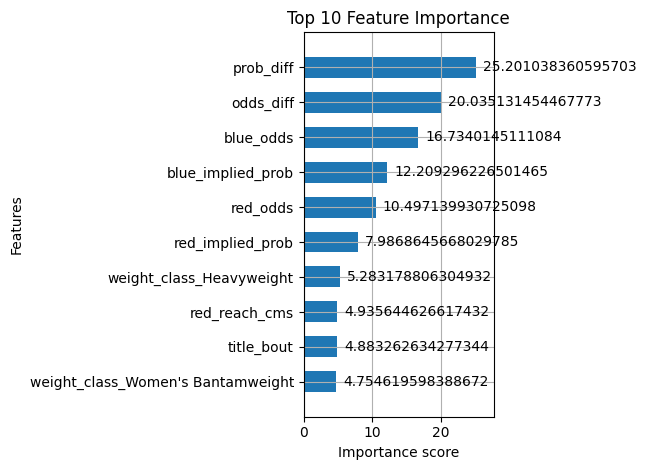

In [38]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plot_importance(
    model,
    max_num_features=10,
    importance_type='gain',   # Better than 'weight'
    height=0.6
)
plt.title("Top 10 Feature Importance")
plt.tight_layout()
plt.show()

Model uses pre booking odds to make predictions. Next model needs to ommit pre-booking odds.

In [29]:
from google.colab import files

uploaded = files.upload()

Saving Garry_vs_makhachev.xlsx to Garry_vs_makhachev.xlsx


In [32]:
new_fight = pd.read_excel("Garry_vs_makhachev.xlsx")
new_fight.head()

,red_odds,blue_odds,odds_diff,age_diff,reach_diff,height_diff,wins_diff,losses_diff,rounds_diff,title_bout_diff,...,red_reach_per_height,blue_reach_per_height,red_days_since_last,blue_days_since_last,red_debut,blue_debut,activity_diff,red_elo,blue_elo,elo_diff
0,-390,280,-670,6,-10,-13,11,0,43,3,...,1,0.9842,273,266,0,0,7,1747.624558,1599.744475,147.880083


In [33]:
prediction = model.predict(new_fight)

In [34]:
probability = model.predict_proba(new_fight)

In [40]:

prediction

array([1])

Model predicts Islam to win the match.

In [36]:
probability

array([[0.33352184, 0.66647816]], dtype=float32)

Probability of Islam winning is 66.64%.
Probability of Ian winning is 33.35%